# Label-Channel Bias All Model All Domain Comparison
This notebook generates plots for comparing models to determine if each one displays label channel bias on high positive case across all domains and models.
Load data by running `data_processing.ipynb` first.

## Setup

In [1]:
import re
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
os.chdir("../..")

## Lookup Maps and Style Constants

In [3]:
rewards_per_scale = {
    'high_scale':     [75, 50, 25],
    'low_scale':      [0.75, 0.5, 0.25],
    'high_neg_scale': [-25, -50, -75],
    'low_neg_scale':  [-0.25, -0.5, -0.75],
}

STYLE_CONSTANTS = {
    'max_val': {
        'linestyle': '--',
        'color': 'black',
        'label': 'Maximum',
    },
    'min_val': {
        'linestyle': '--',
        'color': 'dimgray',
        'label': 'Minimum',
    },
}

# Color per (scale, nomenclature):
#   high_scale (High+)    → warm hues, dark→medium→light
#   high_neg_scale (High−) → cold hues, dark→medium→light
SCALE_NOM_COLORS = {
    'high_scale': {
        'alphanumeric':     '#7B241C',  # dark brick red
        'ordinal_helpful':  '#CA6F1E',  # medium amber
        'ordinal_mislead':  '#CA6F1E',
        'world_helpful':    '#F0B27A',  # light peach-orange
        'world_mislead':    '#F0B27A',
        'sent_new_helpful': '#F9E4B7',  # very light warm
        'sent_new_mislead': '#F9E4B7',
    },
    'high_neg_scale': {
        'alphanumeric':     '#1A5276',  # dark navy
        'ordinal_helpful':  '#2E86C1',  # medium blue
        'ordinal_mislead':  '#2E86C1',
        'world_helpful':    '#85C1E9',  # light sky blue
        'world_mislead':    '#85C1E9',
        'sent_new_helpful': '#D6EAF8',  # very light blue
        'sent_new_mislead': '#D6EAF8',
    },
}

SCALE_LABELS = {'high_scale': 'High+', 'high_neg_scale': 'High−'}

# Nomenclature → marker + linestyle (color comes from SCALE_NOM_COLORS)
NOM_STYLES = {
    'alphanumeric':     {'marker': 'o', 'linestyle': '-',  'label': 'Alphanumeric'},
    'ordinal_helpful':  {'marker': 's', 'linestyle': '--', 'label': 'Ordinal - Helpful'},
    'ordinal_mislead':  {'marker': 's', 'linestyle': '--', 'label': 'Ordinal - Misleading'},
    'world_helpful':    {'marker': '^', 'linestyle': ':',  'label': 'World - Helpful'},
    'world_mislead':    {'marker': '^', 'linestyle': ':',  'label': 'World - Misleading'},
    'sent_new_helpful': {'marker': 'D', 'linestyle': '-.', 'label': 'Sentiment - Helpful'},
    'sent_new_mislead': {'marker': 'D', 'linestyle': '-.', 'label': 'Sentiment - Misleading'},
}

nom_legend_order = [
    'alphanumeric',
    'ordinal_mislead',
    'world_mislead',
    'sent_new_mislead',
]

nomenclature_map = {
    'alphanumeric':     'Alphanumeric',
    'ordinal_helpful':  'Ordinal - Helpful',
    'ordinal_mislead':  'Ordinal - Misleading',
    'world_helpful':    'World - Helpful',
    'world_mislead':    'World - Misleading',
    'sent_new_helpful': 'Sentiment - Helpful',
    'sent_new_mislead': 'Sentiment - Misleading',
}

metric_map = {
    'cum_regret':        'Scaled Cum. Regret',
    'exploration_count': 'States Explored',
}

# Classical baseline styles: TS and UCB1, one line per scale.
# Colour encodes scale sign: mustard/yellow = High+, teal = High−.
# These hues are deliberately distinct from the brick-red/navy palette used for LLM lines.
# Linestyle distinguishes algorithm: TS = dashed, UCB1 = dash-dot.
BASELINE_STYLES = {
    'TS': {
        'high_scale':     {'color': '#C9A227', 'linestyle': '--',  'linewidth': 2.0, 'label': 'TS (High+)'},
        'high_neg_scale': {'color': '#117A65', 'linestyle': '--',  'linewidth': 2.0, 'label': 'TS (High−)'},
    },
    'UCB1': {
        'high_scale':     {'color': '#D4B44A', 'linestyle': '-.',  'linewidth': 2.0, 'label': 'UCB1 (High+)'},
        'high_neg_scale': {'color': '#1ABC9C', 'linestyle': '-.',  'linewidth': 2.0, 'label': 'UCB1 (High−)'},
    },
}

## Configuration

In [4]:
# Load merged results from data_processing.ipynb output
results_df = pd.read_csv('experiments/merged_sem_var_results.csv')
print(f"Loaded {len(results_df)} rows")
results_df[['domain', 'model', 'history', 'variance']].value_counts().reset_index(name='count')

Loaded 1541 rows


,domain,model,history,variance,count
0,Farm,Llama3-8B,Summarized,Low,36
1,Farm,Qwen3-32B,Summarized,No,36
2,Farm,Qwen3-32B,Summarized,Low,36
3,Farm,Qwen3-32B,Summarized,High,36
4,Farm,Llama3-8B,Summarized,High,36
...,...,...,...,...,...
59,Classical,TS,Symbolic,No,2
60,Classical,UCB1,Symbolic,No,2
61,Classical,TS,Symbolic,Low,2
62,Classical,TS,Symbolic,High,2


In [5]:
# Metrics to plot
metrics = ['cum_regret', 'exploration_count']

# Scales to compare
SCALES = ['high_scale', 'high_neg_scale']

# Nomenclatures to compare (missing data silently skipped per domain)
target_nomenclatures = ['alphanumeric', 'ordinal_mislead', 'world_mislead']
domain_nomenclatures = {
    'Farm':                    target_nomenclatures,
    'Clothing Recommendation': target_nomenclatures,
    'Bandit':                  target_nomenclatures,
}

# Preferred domain column order (any not in this list are appended at the end)
domain_order = ['Bandit', 'Farm', 'Clothing Recommendation']

# Variance conditions to generate separate figures for
all_variances = ['No', 'Low', 'High']

# History filter
hist = 'Summarized'

## Plotting Section 1 - OLD

One figure per model × metric × variance. Each figure has one subplot per domain (columns).
Each subplot shows one line per nomenclature, all for the `high_scale` (positive high) condition.

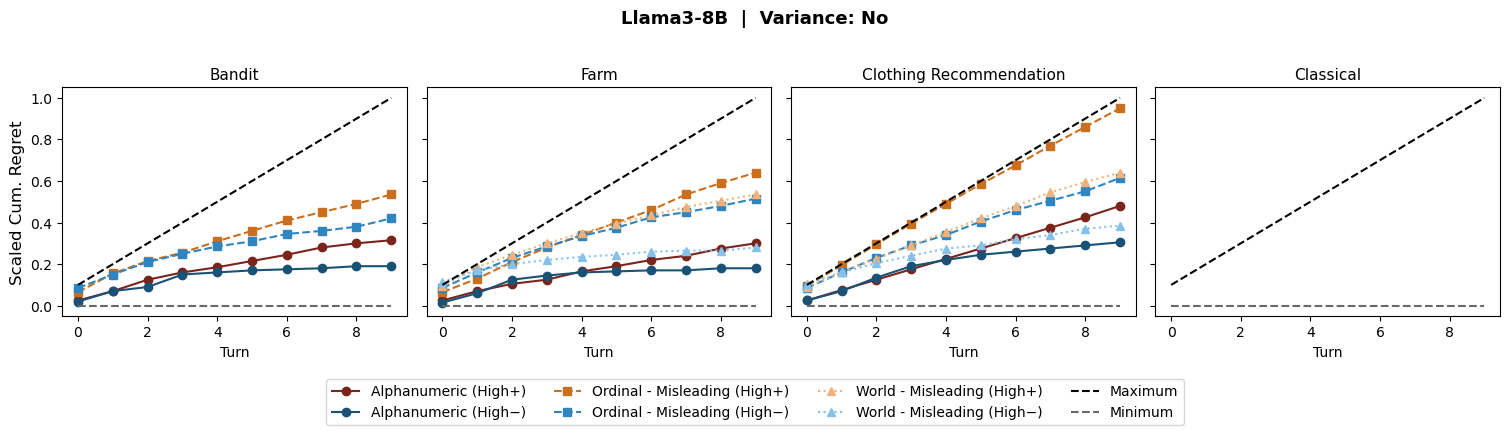

Saved: model=Llama3-8B, metric=cum_regret, variance=No


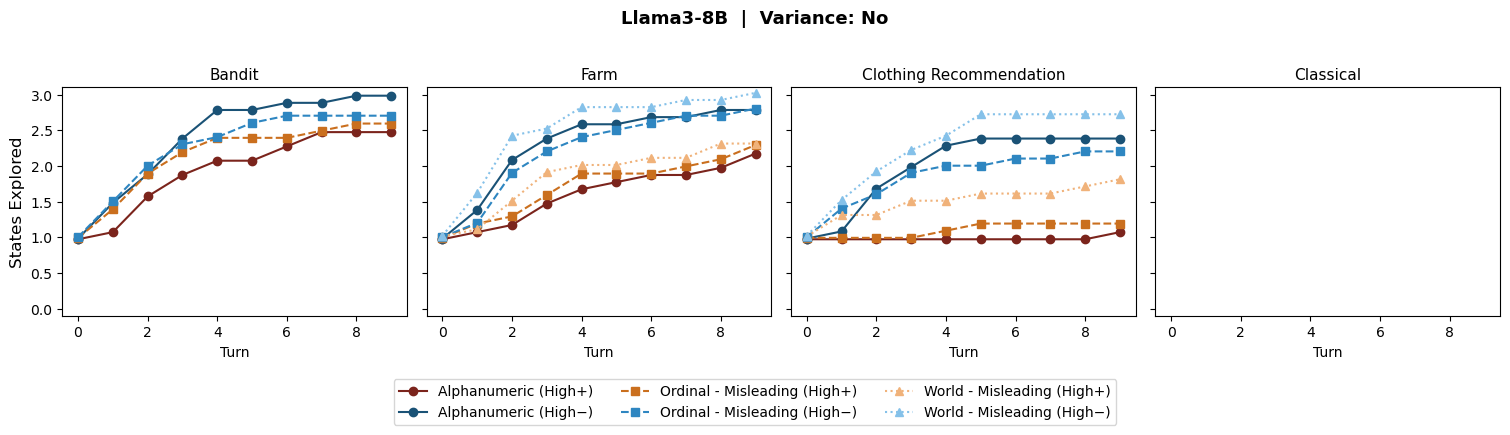

Saved: model=Llama3-8B, metric=exploration_count, variance=No


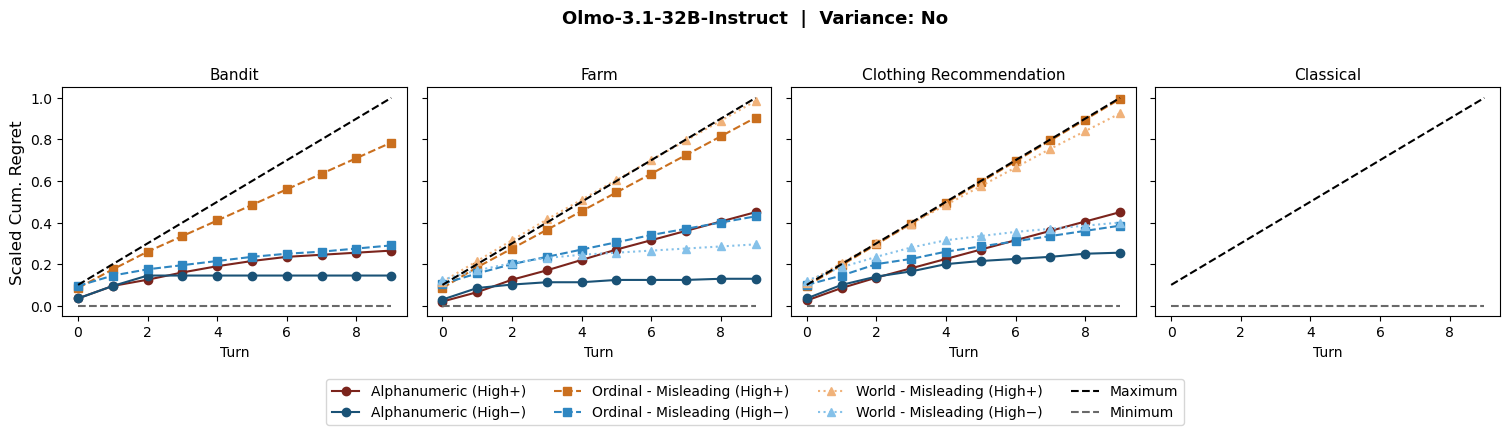

Saved: model=Olmo-3.1-32B-Instruct, metric=cum_regret, variance=No


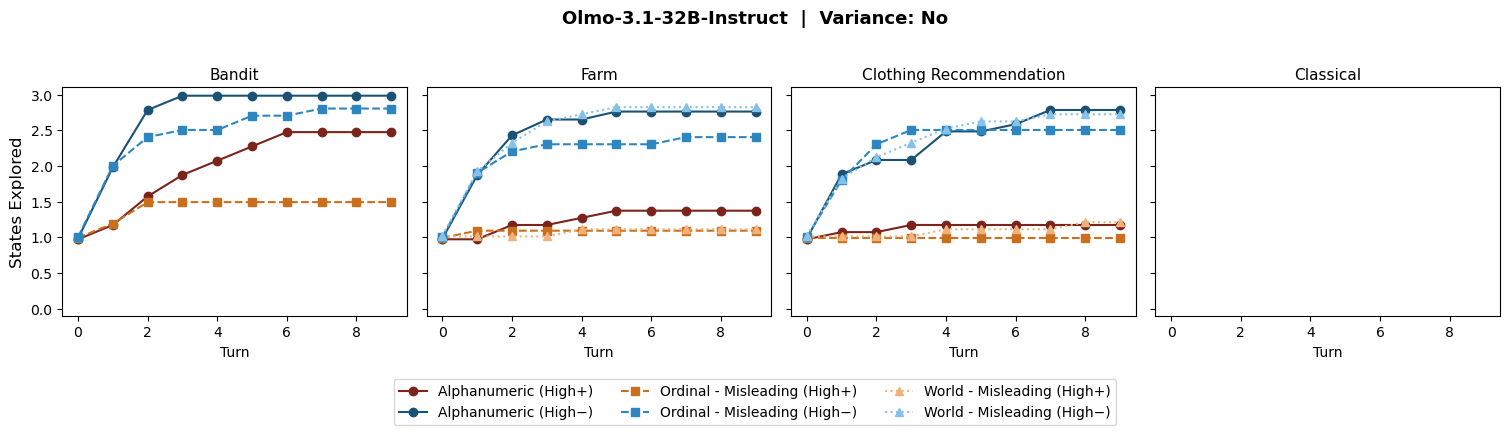

Saved: model=Olmo-3.1-32B-Instruct, metric=exploration_count, variance=No


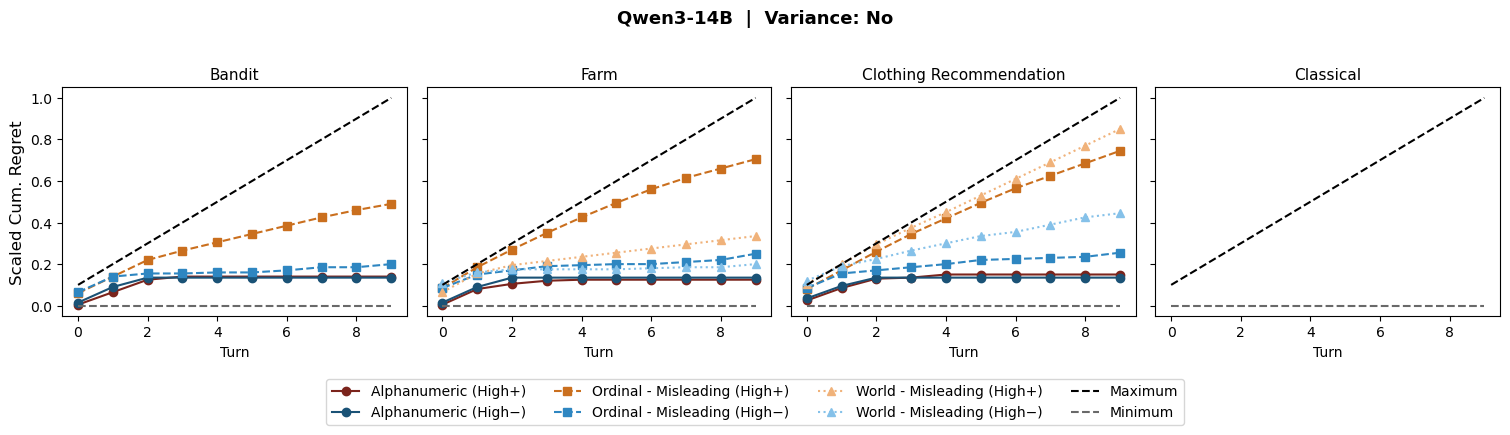

Saved: model=Qwen3-14B, metric=cum_regret, variance=No


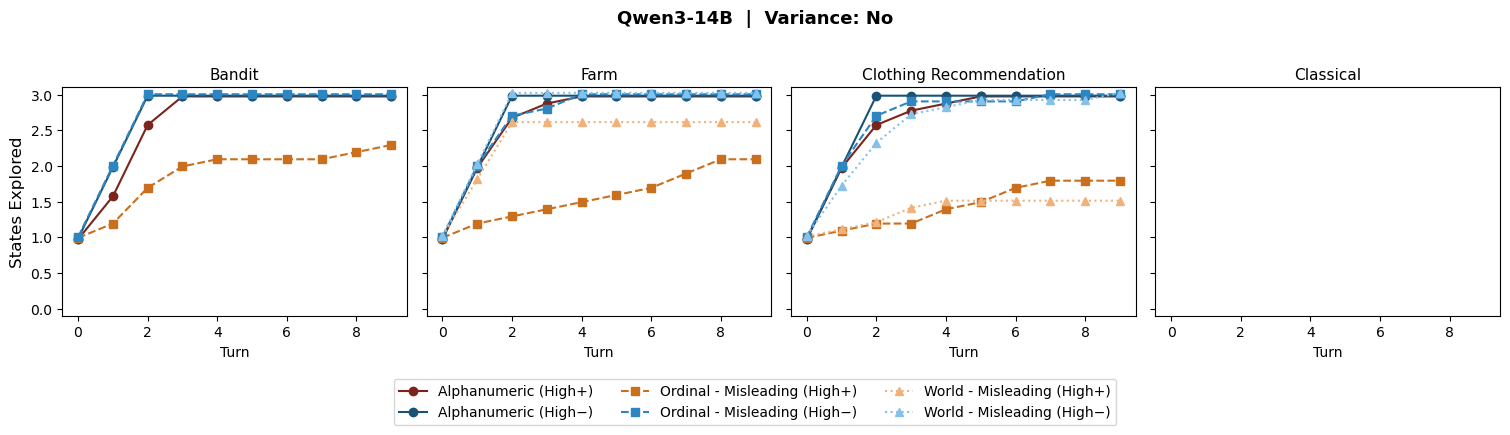

Saved: model=Qwen3-14B, metric=exploration_count, variance=No


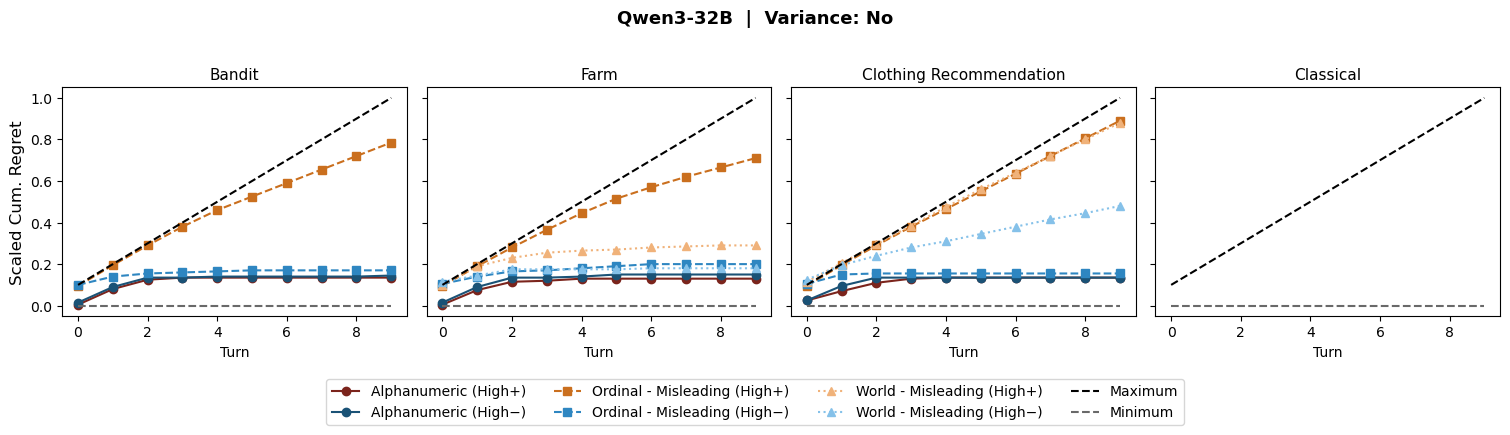

Saved: model=Qwen3-32B, metric=cum_regret, variance=No


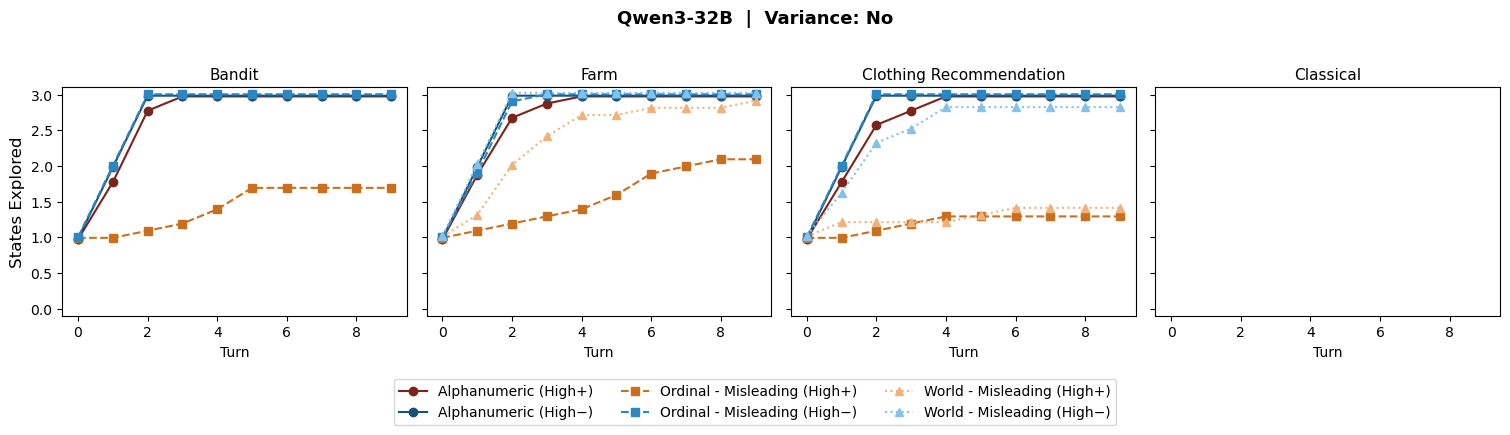

Saved: model=Qwen3-32B, metric=exploration_count, variance=No


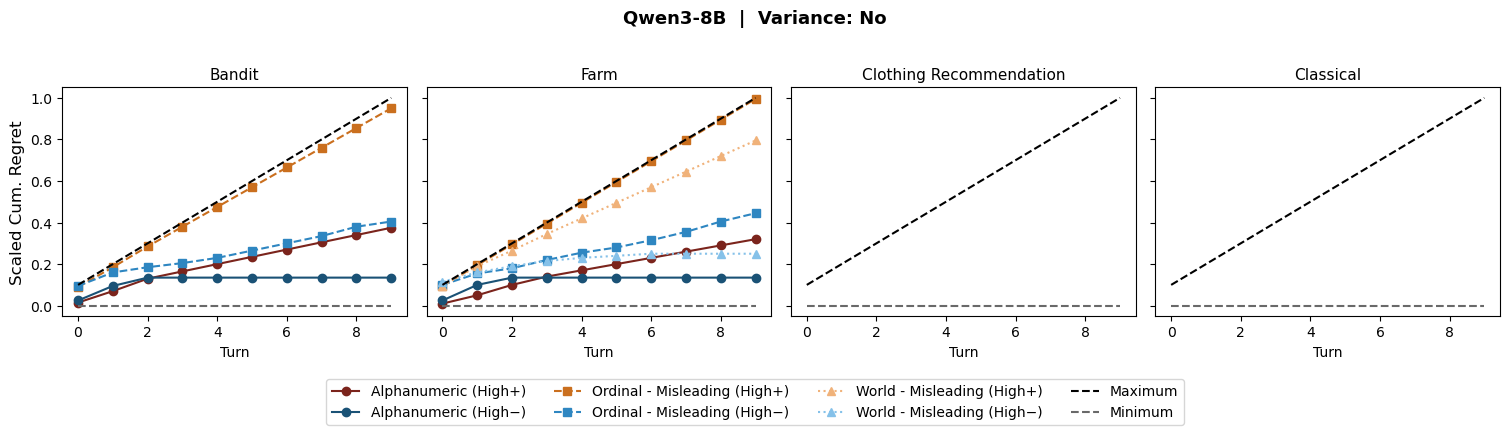

Saved: model=Qwen3-8B, metric=cum_regret, variance=No


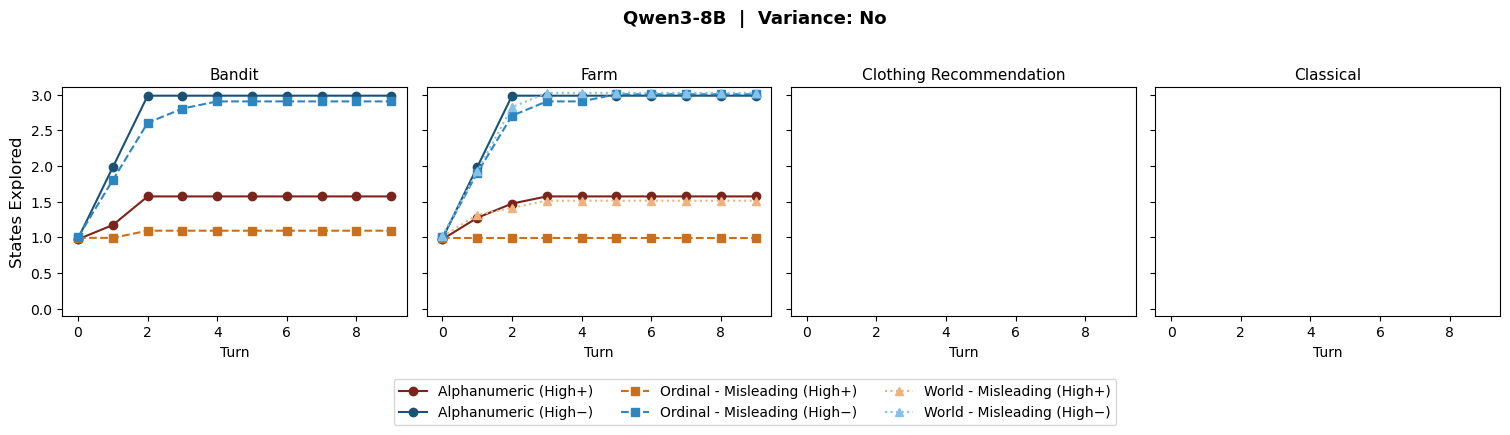

Saved: model=Qwen3-8B, metric=exploration_count, variance=No
No data for model=TS, variance=No — skipping.
No data for model=UCB1, variance=No — skipping.


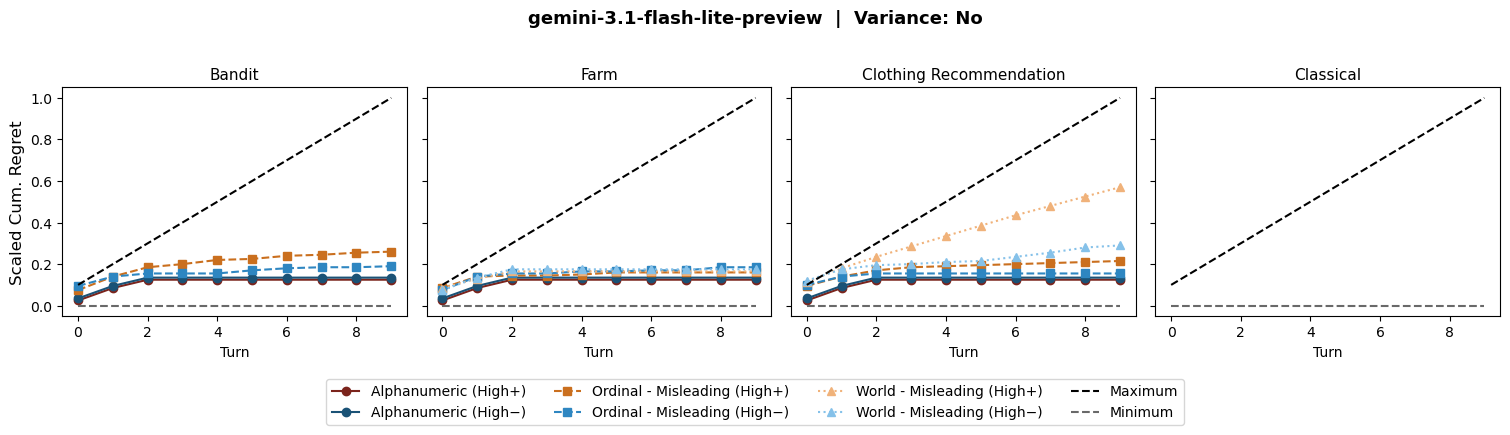

Saved: model=gemini-3.1-flash-lite-preview, metric=cum_regret, variance=No


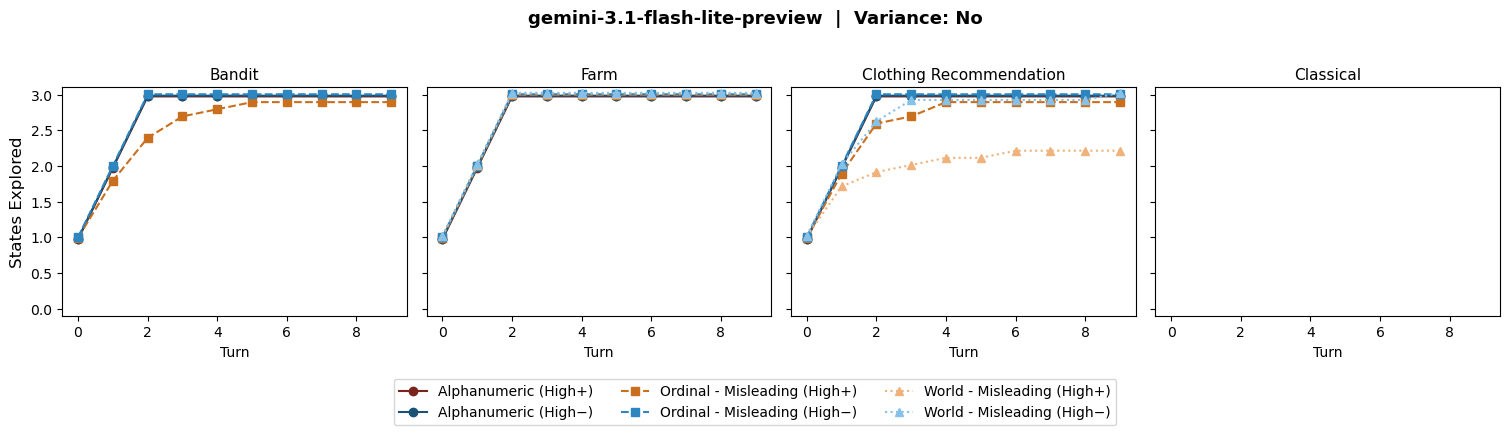

Saved: model=gemini-3.1-flash-lite-preview, metric=exploration_count, variance=No


In [6]:
all_models = sorted(results_df['model'].unique())

# Ordered domain list, restricted to those present in the data
present_domains = results_df['domain'].unique()
domains = [d for d in domain_order if d in present_domains] + \
          [d for d in present_domains if d not in domain_order]

# Extract turn numbers once from column names
turn_numbers = sorted(
    int(col.split('_')[-2])
    for col in results_df.columns
    if col.startswith('cum_regret_') and col.endswith('_mean')
)

# Deterministic vertical jitter: small constant offset per (nom, scale) combo
_jitter_combos = [(nom, scale) for nom in target_nomenclatures for scale in SCALES]
_jitter_step = 0.01
_jitter_offsets = {
    combo: (i - (len(_jitter_combos) - 1) / 2) * _jitter_step
    for i, combo in enumerate(_jitter_combos)
}

for model in all_models:
    model_safe = re.sub(r'[^\w\-]', '_', model)

    for variance in all_variances:
        variance_safe = variance.lower()
        if variance_safe in ['low', 'high']:
            continue
        subset = results_df[
            (results_df['model']    == model)   &
            (results_df['history']  == hist)    &
            (results_df['variance'] == variance)
        ]
        if subset.empty:
            print(f"No data for model={model}, variance={variance} — skipping.")
            continue

        for metric_name in metrics:
            legend_ncol = 3 if metric_name == 'exploration_count' else 4

            fig, axes = plt.subplots(
                1, len(domains),
                figsize=(3.8 * len(domains), 4.8),
                sharex=True, sharey=True,
            )
            if len(domains) == 1:
                axes = [axes]

            fig.suptitle(f"{model}  |  Variance: {variance}", fontsize=13, fontweight='bold')

            label_to_handle = {}

            for col_idx, domain in enumerate(domains):
                ax = axes[col_idx]
                domain_subset = subset[subset['domain'] == domain]
                nomenclatures = domain_nomenclatures.get(domain, [])

                for nom_key in nomenclatures:
                    for scale in SCALES:
                        nom_df = domain_subset[
                            domain_subset['nomenclature'].str.contains(nom_key, na=False) &
                            (domain_subset['scale'] == scale)
                        ]
                        if nom_df.empty:
                            continue

                        means = nom_df[[f"{metric_name}_{t}_mean" for t in turn_numbers]].values.flatten()

                        if metric_name == 'cum_regret':
                            normalizing_constant = (
                                max(rewards_per_scale[scale]) - min(rewards_per_scale[scale])
                            ) * len(means)
                            means = [x / normalizing_constant for x in means]

                        offset = _jitter_offsets.get((nom_key, scale), 0.0)
                        y_vals = [y + offset for y in means]

                        nom_style = NOM_STYLES[nom_key]
                        label = f"{nom_style['label']} ({SCALE_LABELS[scale]})"
                        style = {
                            'color':     SCALE_NOM_COLORS[scale][nom_key],
                            'marker':    nom_style['marker'],
                            'linestyle': nom_style['linestyle'],
                            'label':     label,
                        }
                        try:
                            handle, = ax.plot(turn_numbers, y_vals, **style)
                            if label not in label_to_handle:
                                label_to_handle[label] = handle
                        except Exception as e:
                            print(f"ERROR: model={model} domain={domain} nom={nom_key} scale={scale}: {e}")

                # Min / max reference bounds for cum_regret
                if metric_name == 'cum_regret' and len(turn_numbers) > 0:
                    max_step = 1.0 / len(turn_numbers)
                    bounds = {
                        'max_val': list(np.linspace(max_step, 1.0, len(turn_numbers))),
                        'min_val': [0.0] * len(turn_numbers),
                    }
                    for bound_key, bound_vals in bounds.items():
                        handle, = ax.plot(turn_numbers, bound_vals, **STYLE_CONSTANTS[bound_key])
                        label = STYLE_CONSTANTS[bound_key]['label']
                        if label not in label_to_handle:
                            label_to_handle[label] = handle

                ax.set_xlabel("Turn")
                ax.set_title(domain, fontsize=11)

                if col_idx == 0:
                    ax.set_ylabel(metric_map[metric_name], fontsize=12)

                if metric_name == 'exploration_count':
                    ax.set_ylim(-0.1, 3.1)

            # Shared legend: nomenclatures × scales first, then bounds
            sorted_labels, sorted_handles = [], []
            for nom in nom_legend_order:
                for scale in SCALES:
                    lbl = f"{NOM_STYLES[nom]['label']} ({SCALE_LABELS[scale]})"
                    if lbl in label_to_handle:
                        sorted_labels.append(lbl)
                        sorted_handles.append(label_to_handle[lbl])
            for k in ['max_val', 'min_val']:
                lbl = STYLE_CONSTANTS[k]['label']
                if lbl in label_to_handle:
                    sorted_labels.append(lbl)
                    sorted_handles.append(label_to_handle[lbl])

            fig.legend(
                sorted_handles, sorted_labels,
                loc='lower center', bbox_to_anchor=(0.5, 0.1),
                ncol=legend_ncol, borderaxespad=0.5, frameon=True, fontsize=10,
            )
            plt.tight_layout(rect=[0, 0.22, 1, 0.96])

            out_dir     = f"figures/scale_{metric_name}/{model_safe}"
            out_dir_png = f"figures_png/scale_{metric_name}/{model_safe}"
            os.makedirs(out_dir,     exist_ok=True)
            os.makedirs(out_dir_png, exist_ok=True)
            plt.savefig(f"{out_dir}/variance_{variance_safe}.pdf",     dpi=300, bbox_inches='tight')
            plt.savefig(f"{out_dir_png}/variance_{variance_safe}.png", dpi=300, bbox_inches='tight')

            plt.show()
            print(f"Saved: model={model}, metric={metric_name}, variance={variance}")

## Plotting Section 2 - Current

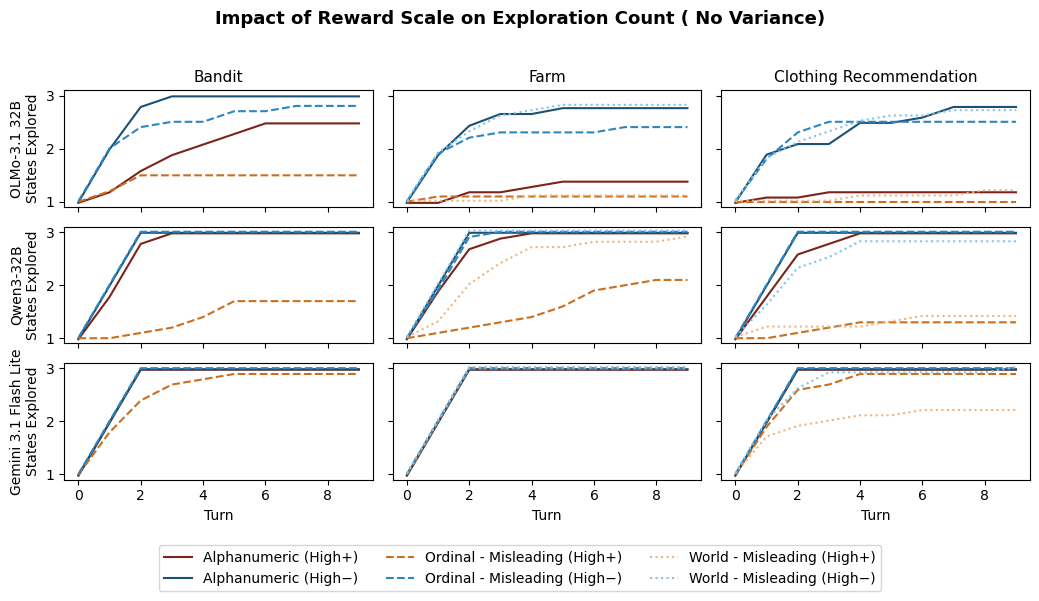

Saved three-model exploration_count: variance=No


In [7]:
THREE_MODELS = [
    ('Olmo-3.1-32B-Instruct',        'OLMo-3.1 32B'),
    ('Qwen3-32B',                     'Qwen3-32B'),
    ('gemini-3.1-flash-lite-preview', 'Gemini 3.1 Flash Lite'),
]

plot_domains = [d for d in domains if d != 'Classical']

for variance in all_variances:
    variance_safe = variance.lower()
    if variance_safe in ['low', 'high']:
        continue

    fig, axes = plt.subplots(
        len(THREE_MODELS), len(plot_domains),
        figsize=(3.5 * len(plot_domains), 2 * len(THREE_MODELS)),
        sharex=True, sharey=True,
    )
    if len(plot_domains) == 1:
        axes = axes.reshape(len(THREE_MODELS), 1)

    fig.suptitle(f"Exploration Count by Model  |  Variance: {variance}", fontsize=13, fontweight='bold')

    label_to_handle = {}

    for model_idx, (model, model_label) in enumerate(THREE_MODELS):
        subset = results_df[
            (results_df['model']    == model)   &
            (results_df['history']  == hist)    &
            (results_df['variance'] == variance)
        ]

        for col_idx, domain in enumerate(plot_domains):
            ax = axes[model_idx, col_idx]

            if subset.empty:
                ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
            else:
                domain_subset = subset[subset['domain'] == domain]
                nomenclatures = domain_nomenclatures.get(domain, [])

                for nom_key in nomenclatures:
                    for scale in SCALES:
                        nom_df = domain_subset[
                            domain_subset['nomenclature'].str.contains(nom_key, na=False) &
                            (domain_subset['scale'] == scale)
                        ]
                        if nom_df.empty:
                            continue

                        means = nom_df[[f"exploration_count_{t}_mean" for t in turn_numbers]].values.flatten()
                        offset = _jitter_offsets.get((nom_key, scale), 0.0)
                        y_vals = [y + offset for y in means]

                        nom_style = NOM_STYLES[nom_key]
                        label = f"{nom_style['label']} ({SCALE_LABELS[scale]})"
                        style = {
                            'color':     SCALE_NOM_COLORS[scale][nom_key],
                            'marker':    '',
                            'linestyle': nom_style['linestyle'],
                            'label':     label,
                        }
                        try:
                            handle, = ax.plot(turn_numbers, y_vals, **style)
                            if label not in label_to_handle:
                                label_to_handle[label] = handle
                        except Exception as e:
                            print(f"ERROR: model={model} domain={domain} nom={nom_key} scale={scale}: {e}")

            if model_idx == len(THREE_MODELS) - 1:
                ax.set_xlabel("Turn")
            if model_idx == 0:
                ax.set_title(domain, fontsize=11)
            if col_idx == 0:
                ax.set_ylabel(f"{model_label}\n{metric_map['exploration_count']}", fontsize=10)
            ax.set_ylim(0.9, 3.1)

    # # Overlay TS and UCB1 baselines on all subplots.
    # for bl_model in ['TS', 'UCB1']:
    #     for scale in SCALES:
    #         bl_row = results_df[
    #             (results_df['model']        == bl_model) &
    #             (results_df['variance']     == variance) &
    #             (results_df['scale']        == scale) &
    #             (results_df['nomenclature'] == 'baseline')
    #         ]
    #         if bl_row.empty:
    #             continue
    #         y_vals = bl_row[[f"exploration_count_{t}_mean" for t in turn_numbers]].values.flatten()
    #         style = BASELINE_STYLES[bl_model][scale]
    #         for model_idx in range(len(THREE_MODELS)):
    #             for col_idx in range(len(plot_domains)):
    #                 handle, = axes[model_idx, col_idx].plot(turn_numbers, y_vals, **style)
    #         label = style['label']
    #         if label not in label_to_handle:
    #             label_to_handle[label] = handle

    # Two-row legend: High+ (positive) on row 1, High− (negative) on row 2.
    # Build by interleaving (High+, High−) pairs per entry; matplotlib fills
    # column-by-column, so ncol = number of pairs gives the correct layout.
    pos_labels, pos_handles = [], []
    neg_labels, neg_handles = [], []

    for nom in nom_legend_order:
        lbl_pos = f"{NOM_STYLES[nom]['label']} ({SCALE_LABELS['high_scale']})"
        lbl_neg = f"{NOM_STYLES[nom]['label']} ({SCALE_LABELS['high_neg_scale']})"
        if lbl_pos in label_to_handle:
            pos_labels.append(lbl_pos);  pos_handles.append(label_to_handle[lbl_pos])
        if lbl_neg in label_to_handle:
            neg_labels.append(lbl_neg);  neg_handles.append(label_to_handle[lbl_neg])

    # for bl_model in ['TS', 'UCB1']:
    #     lbl_pos = BASELINE_STYLES[bl_model]['high_scale']['label']
    #     lbl_neg = BASELINE_STYLES[bl_model]['high_neg_scale']['label']
    #     if lbl_pos in label_to_handle:
    #         pos_labels.append(lbl_pos);  pos_handles.append(label_to_handle[lbl_pos])
    #     if lbl_neg in label_to_handle:
    #         neg_labels.append(lbl_neg);  neg_handles.append(label_to_handle[lbl_neg])

    # Interleave so column-major fill gives row 1 = pos, row 2 = neg
    sorted_labels  = [x for pair in zip(pos_labels,  neg_labels)  for x in pair]
    sorted_handles = [x for pair in zip(pos_handles, neg_handles) for x in pair]
    ncol = len(pos_labels)

    fig.legend(
        sorted_handles, sorted_labels,
        loc='lower center', bbox_to_anchor=(0.5, 0.0),
        ncol=ncol, borderaxespad=0.5, frameon=True, fontsize=10,
    )
    plt.tight_layout(rect=[0, 0.10, 1, 0.96])

    if variance.lower() == "no":
        fig.suptitle(f"Impact of Reward Scale on Exploration Count ( No Variance)", fontsize=13, fontweight='bold')

        out_dir     = "figures/main"
        out_dir_png = "figures_png/main"
        os.makedirs(out_dir,     exist_ok=True)
        os.makedirs(out_dir_png, exist_ok=True)
        plt.savefig(f"{out_dir}/scale_impact_on_exp.pdf",     dpi=300, bbox_inches='tight')
        plt.savefig(f"{out_dir_png}/scale_impact_on_exp.png", dpi=300, bbox_inches='tight')

    out_dir     = "figures/exploration_count/three_model_comparison_scale"
    out_dir_png = "figures_png/exploration_count/three_model_comparison_scale"
    os.makedirs(out_dir,     exist_ok=True)
    os.makedirs(out_dir_png, exist_ok=True)
    plt.savefig(f"{out_dir}/scale_variance_{variance_safe}.pdf",     dpi=300, bbox_inches='tight')
    plt.savefig(f"{out_dir_png}/scale_variance_{variance_safe}.png", dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved three-model exploration_count: variance={variance}")